# MATRIX Testbed — Actuator & Sensor Timing Analysis
This Jupyter notebook dynamically loads, processes, and evaluates `turntable_timing.csv`, `transfer_unit_timing.csv`, and `conveyor_timing.csv` to cleanly reconstruct precise **Digital Timing Diagrams**.

### Features:
* Automatically maps sequential **HIGH/LOW** states into chronological square wave pulses.
* Calculates exact step offsets using incremental captured duration values.
* Generates flat, stacked subplots using **Matplotlib** for deep operational cycle analytics.

Author: Kananelo Chabeli

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_and_process_timing_csv(filepath, global_start):
    """
    Reads a timing CSV and reconstructs the waveform using ABSOLUTE elapsed
    time relative to a single global_start reference shared across ALL
    zones — so actuators, sensors, and every stage's diagram sit on one
    common time axis and can be directly compared for full-system
    operability analysis.
    """
    if not os.path.exists(filepath):
        print(f"⚠️ Warning: File {filepath} not found. Skipping.")
        return {}

    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"❌ Error reading {filepath}: {e}")
        return {}

    if df.empty:
        print(f"ℹ️ File {filepath} is empty.")
        return {}

    # Standardise column data types
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Duration_Sec'] = pd.to_numeric(df['Duration_Sec'], errors='coerce').fillna(0.0)
    # NOTE: fixed HIGH/LOW mapping (previously inverted: HIGH was mapped to 0)
    df['State'] = df['State'].astype(str).str.upper().map({'HIGH': 1, 'LOW': 0}).fillna(0)

    df = df.sort_values(by='Timestamp').reset_index(drop=True)

    tag_waveforms = {}
    grouped = df.groupby('Tag_Name')

    for tag, group in grouped:
        group = group.sort_values(by='Timestamp')

        # Each row's Timestamp marks the instant the tag LEFT the state
        # recorded in 'State', after holding it for 'Duration_Sec'.
        end_abs = group['Timestamp']
        start_abs = end_abs - pd.to_timedelta(group['Duration_Sec'], unit='s')

        # Convert to elapsed seconds from the single shared reference point
        rel_start = (start_abs - global_start).dt.total_seconds().to_numpy()
        rel_end = (end_abs - global_start).dt.total_seconds().to_numpy()
        held_state = group['State'].to_numpy()

        t_coords = []
        state_coords = []
        for s, e, v in zip(rel_start, rel_end, held_state):
            t_coords.extend([s, e])
            state_coords.extend([v, v])

        tag_waveforms[tag] = (np.array(t_coords), np.array(state_coords))

    return tag_waveforms


In [3]:
def plot_digital_timing_diagram(zone_name, waveforms):
    """
    Generates a clean, stacked multi-row digital timing diagram layout.
    """
    if not waveforms:
        print(f"No valid state logic sequences found to plot for Zone: {zone_name}.")
        return

    num_tags = len(waveforms)
    fig, axes = plt.subplots(num_tags, 1, figsize=(12, 2.2 * num_tags), sharex=True)
    
    if num_tags == 1:
        axes = [axes]
        
    fig.suptitle(f"Digital Timing Diagram — {zone_name} Station", fontsize=14, fontweight='bold', y=0.99)
    
    for idx, (tag, (t, states)) in enumerate(waveforms.items()):
        ax = axes[idx]
        
        # Draw clean step traces
        ax.step(t, states, where='post', color='#007acc', linewidth=2.5)
        ax.fill_between(t, states, step="post", color='#007acc', alpha=0.12)
        
        # Format aesthetics
        ax.set_ylabel(tag, rotation=0, ha='right', va='center', fontsize=10, fontweight='bold')
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['LOW', 'HIGH'], fontsize=9)
        ax.grid(True, which='both', linestyle='--', alpha=0.4, color='#ccc')
        
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    axes[-1].set_xlabel("Relative Elapsed Operational Cycle Time (Seconds)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

Global time reference (t=0): 2026-08-30 14:19:09.445046+00:00 UTC


Processing digital waveforms for Turntable Zone...


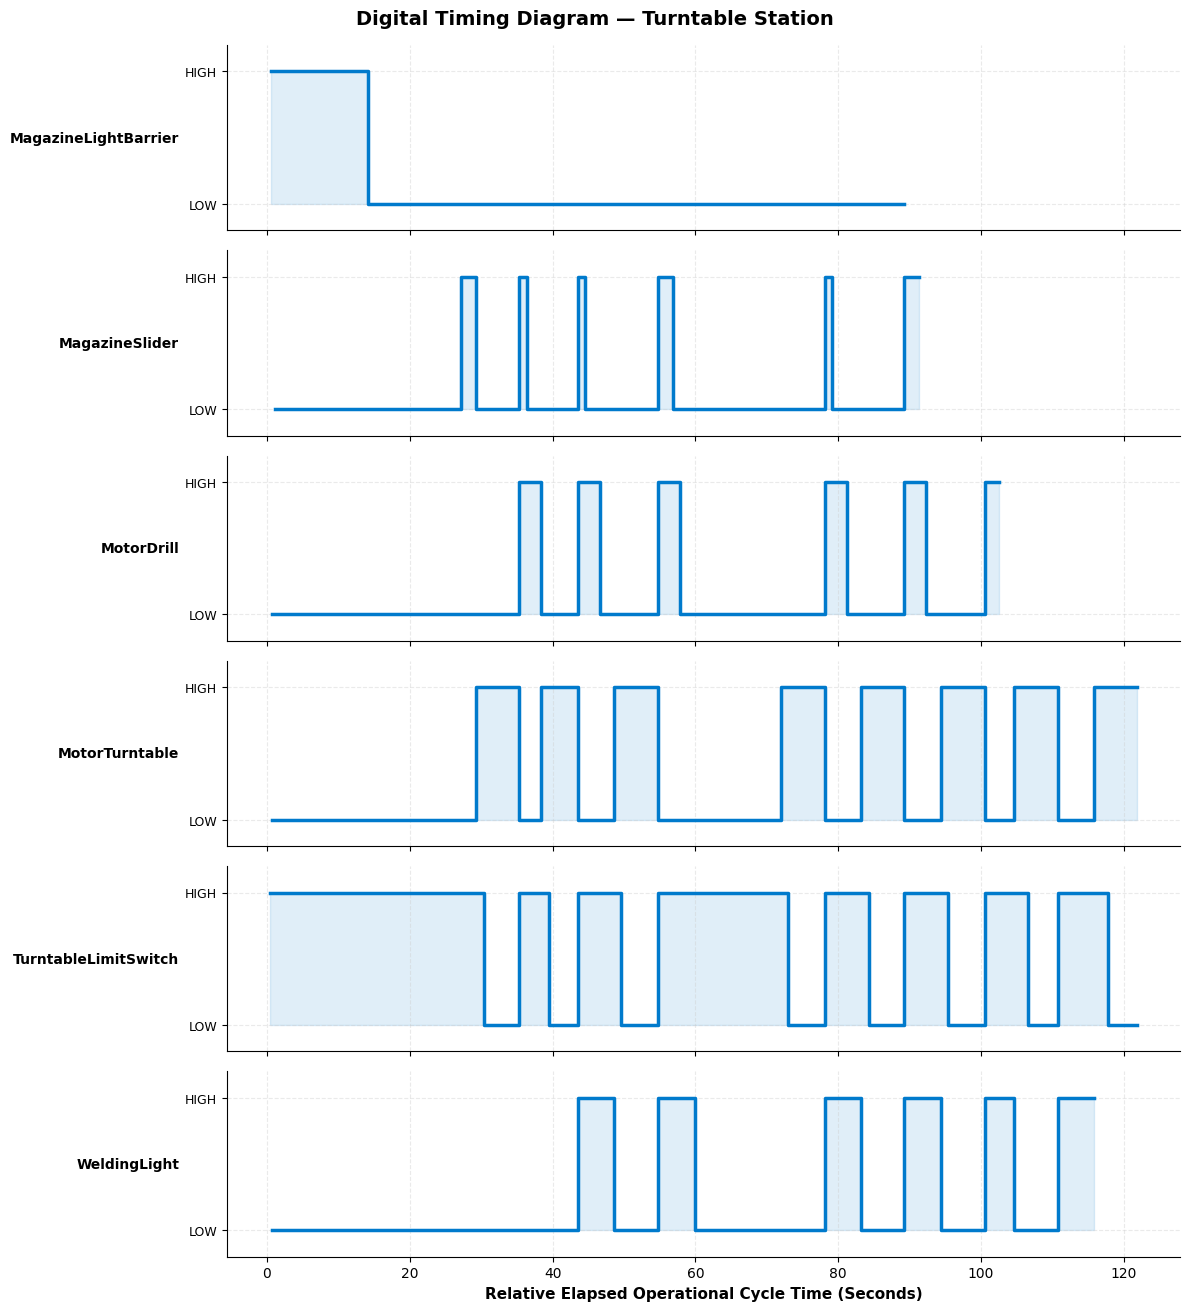


Processing digital waveforms for Transfer Unit Zone...


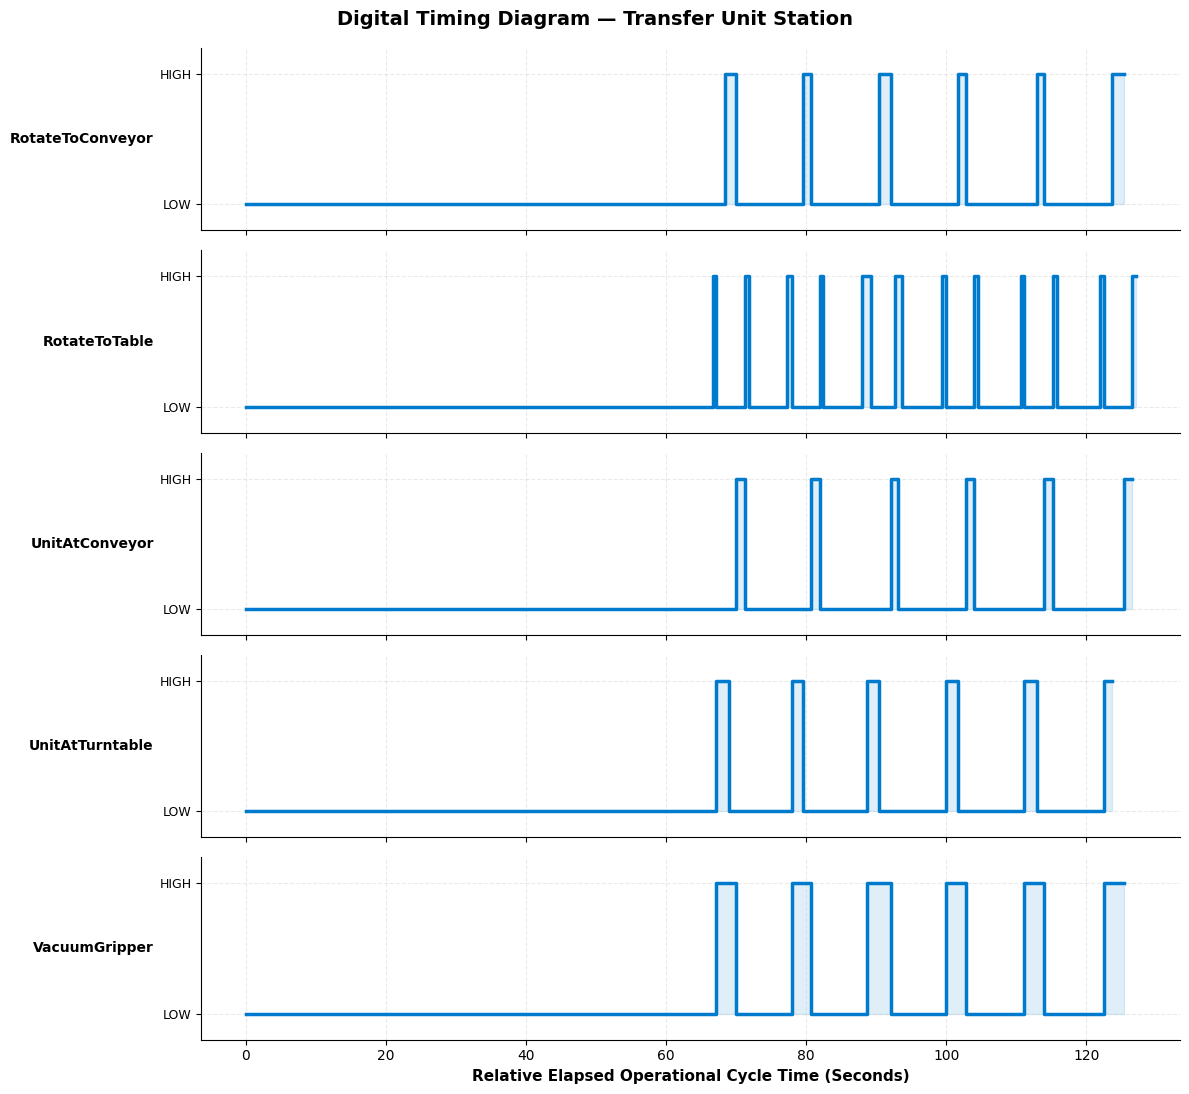


Processing digital waveforms for Conveyor Zone...


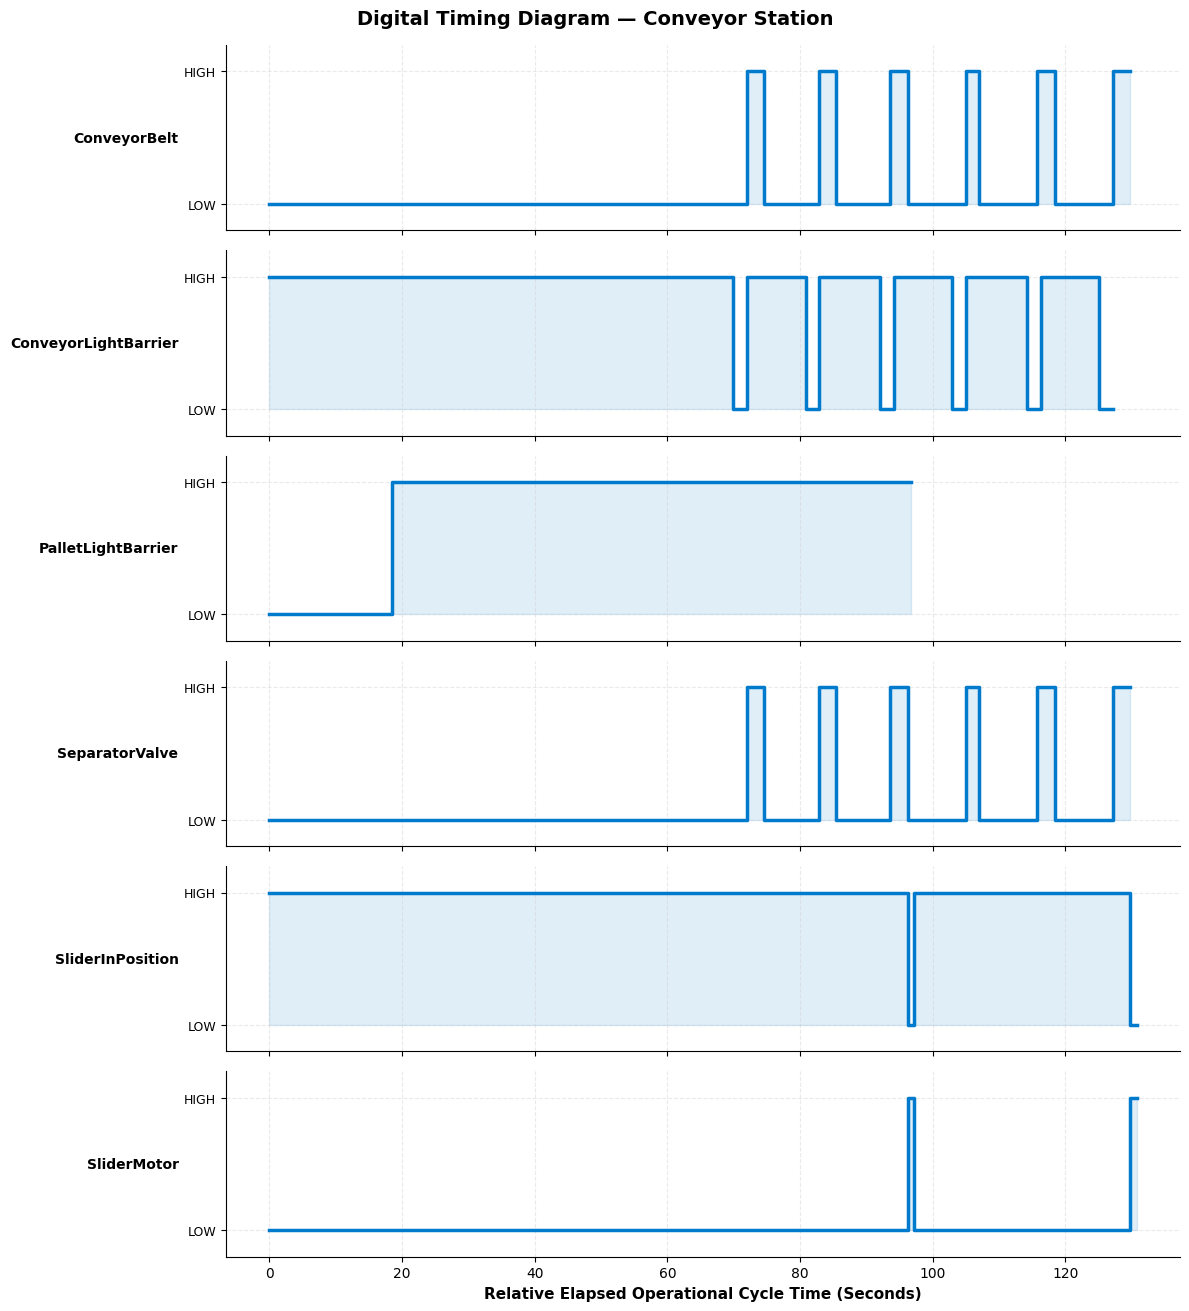

In [5]:
# --- Execution Entry Point ---
files_to_render = {
    "Turntable": "..\\data\\turntable_timing.csv",
    "Transfer Unit": "..\\data\\transfer_unit_timing.csv",
    "Conveyor": "..\\data\\conveyor_timing.csv"
}

def compute_global_start(filenames):
    """
    Scans every zone's CSV and returns the single earliest known instant
    across ALL of them — this becomes t=0 for every timing diagram, so
    actuators, sensors, and all three stages share one real time axis.
    """
    starts = []
    for fname in filenames:
        if not os.path.exists(fname):
            continue
        try:
            df = pd.read_csv(fname)
        except Exception:
            continue
        if df.empty:
            continue
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Duration_Sec'] = pd.to_numeric(df['Duration_Sec'], errors='coerce').fillna(0.0)
        earliest = (df['Timestamp'] - pd.to_timedelta(df['Duration_Sec'], unit='s')).min()
        starts.append(earliest)
    if not starts:
        raise RuntimeError("No timing CSV data found to establish a global time reference.")
    return min(starts)

global_start = compute_global_start(files_to_render.values())
print(f"Global time reference (t=0): {global_start} UTC\n")

for zone, filename in files_to_render.items():
    print(f"\nProcessing digital waveforms for {zone} Zone...")
    zone_data = load_and_process_timing_csv(filename, global_start)
    plot_digital_timing_diagram(zone, zone_data)
